In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from dataclasses import replace

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.tile.bin_1d import Tile2Symb1dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 100
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


def make_converter(params: Params):
    converter = LineConverter(tile_converter=Tile2Symb1dBin(symbols=SYMBOLS,
                                                            font=FONT,
                                                            **params.converter_args))

    return ImgConverter(converter, FONT)

In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

default_params = Params(max_cols=MAX_COLS,
                        max_lines=MAX_LINES,
                        font_path=FONT_PATH,
                        font_size=FONT_SIZE)

converter = make_converter(default_params)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    gens_per_step=default_params.gens_per_step)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| +<v7LcTT1*t?uT*tt=/! | 1P56Gkh1J8AGQgg01mQU | 111V}tt\Lz1FC1111n>; |
| 11111ZV1111114rnf3i* | 1{|fK2&1(1fakyu1nuz( | iTf7)l)()Jl?*>\<;;/< |
| qwODDRR#HHGO8ORDORUo | *s119#14t>."F1{1111T | Y3zFJ121ZE&kX][1dX&1 |
| wDR0$)v7(o#DORG8RPPk | 1111UhK|~",^)25X1ye1 | Y]TTvz1131o11V11x41| |
| AROGbXdZhEH#OOO&Kb6o | FZV1hSPX(,-^Co2ka11? | CxCT3">=cFvv)il\*=\~ |
| b6GRO#HBQNM%G8#Ubde1 | u111P9U5c ,-111X2VX4 | xC1T7"**;-=,=^+?vY11 |
| hG%WN8gN8HHOGD6pKwo1 | 11Tuao96*,i1c`>lI11s | c?[c++icill|j1VZZV21 |
----------------------------------------------------------------------
--------------------------------------------------------------
| ,":.''`'"`-! | OmOGhGGHe1o6OBb11XXU | y2Fn}v*1111o111111zL |
| ++///;/<<;>^ | G8hKK1yPDDDP9SUHpD0M | Xy2XX1CT)vIF1}f3IT1I |
| 11111111111/ | V@988pqVak13t1x(+*1S | 21x4vffJ1x1X2fn|vLfI |
| ZkXV2ZXo5ZV7 | EU%WM$HG9?LLj+,:'_:+ | VUSSoa1{l>c11|4V5V1z |
| 1oVyr1C1XZ5l | ]1[bG&PA<;(/ -_'! ". | akmhXy

Min: -0.0447 | Max: 0.1143 | Mean: 0.0396 | Std: 0.0266
Min: -0.0026 | Max: 0.1503 | Mean: 0.0861 | Std: 0.0302
Min: 0.0032 | Max: 0.1601 | Mean: 0.0853 | Std: 0.0331
Min: -0.0051 | Max: 0.1748 | Mean: 0.0906 | Std: 0.0350
Min: 0.0116 | Max: 0.1702 | Mean: 0.0801 | Std: 0.0303
Min: -0.0060 | Max: 0.1868 | Mean: 0.0843 | Std: 0.0332
Min: 0.0006 | Max: 0.1825 | Mean: 0.0741 | Std: 0.0303
Min: 0.0085 | Max: 0.1630 | Mean: 0.0771 | Std: 0.0293
Min: 0.0123 | Max: 0.1521 | Mean: 0.0776 | Std: 0.0303


C:\Users\wojte\AppData\Local\Temp\ipykernel_23120\264104810.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


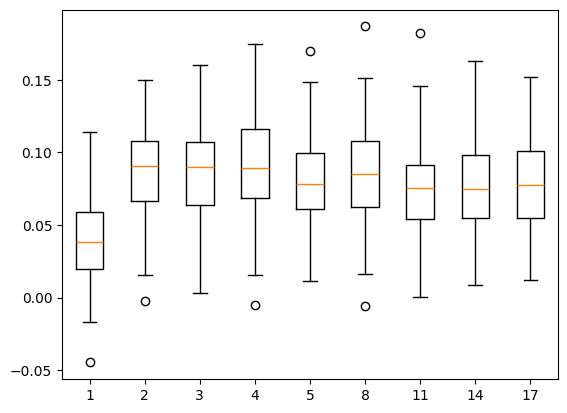

In [3]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: replace(default_params, converter_args={'bins': bins}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: -0.0014 | Max: 0.1171 | Mean: 0.0542 | Std: 0.0255
Min: 0.0086 | Max: 0.1722 | Mean: 0.0686 | Std: 0.0291
Min: 0.0114 | Max: 0.1909 | Mean: 0.0847 | Std: 0.0343
Min: 0.0095 | Max: 0.2007 | Mean: 0.0977 | Std: 0.0371
Min: 0.0215 | Max: 0.1999 | Mean: 0.1046 | Std: 0.0356


C:\Users\wojte\AppData\Local\Temp\ipykernel_23120\2305421242.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


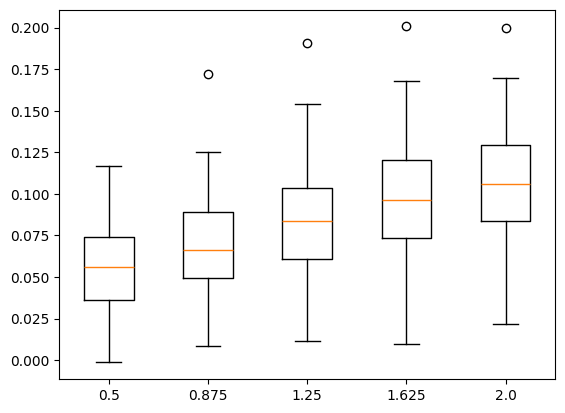

In [4]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: replace(default_params, preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

Min: 0.0108 | Max: 0.1847 | Mean: 0.0782 | Std: 0.0310
Min: -0.0015 | Max: 0.1408 | Mean: 0.0606 | Std: 0.0268
Min: -0.0021 | Max: 0.2240 | Mean: 0.0954 | Std: 0.0486


C:\Users\wojte\AppData\Local\Temp\ipykernel_23120\1162874657.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


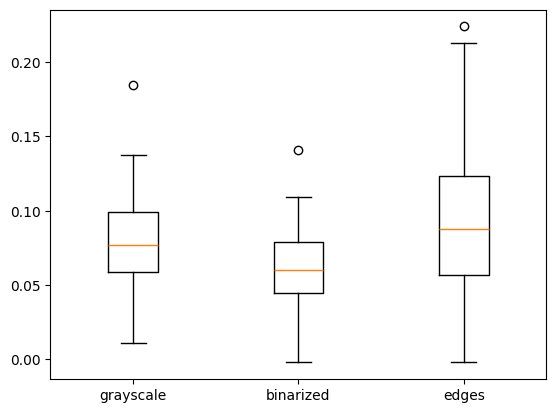

In [5]:
params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()